findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Original CSV: 231 rows
After trimming: 200 rows
Loaded 200 ISM scores
Trimmed sequence length: 200

Searching for specific sequences...

Motif A (TRGYNNARNNG):
  Using sequence: TGGCTCACGCC
  Position: 47
  Mismatches from motif: 2

Motif B (GWTCRANNC):
  Best match at position 111 with 0 mismatches
  Matched sequence: GTTCGAGAC


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.



Saved plot to motif_ism_logos.png


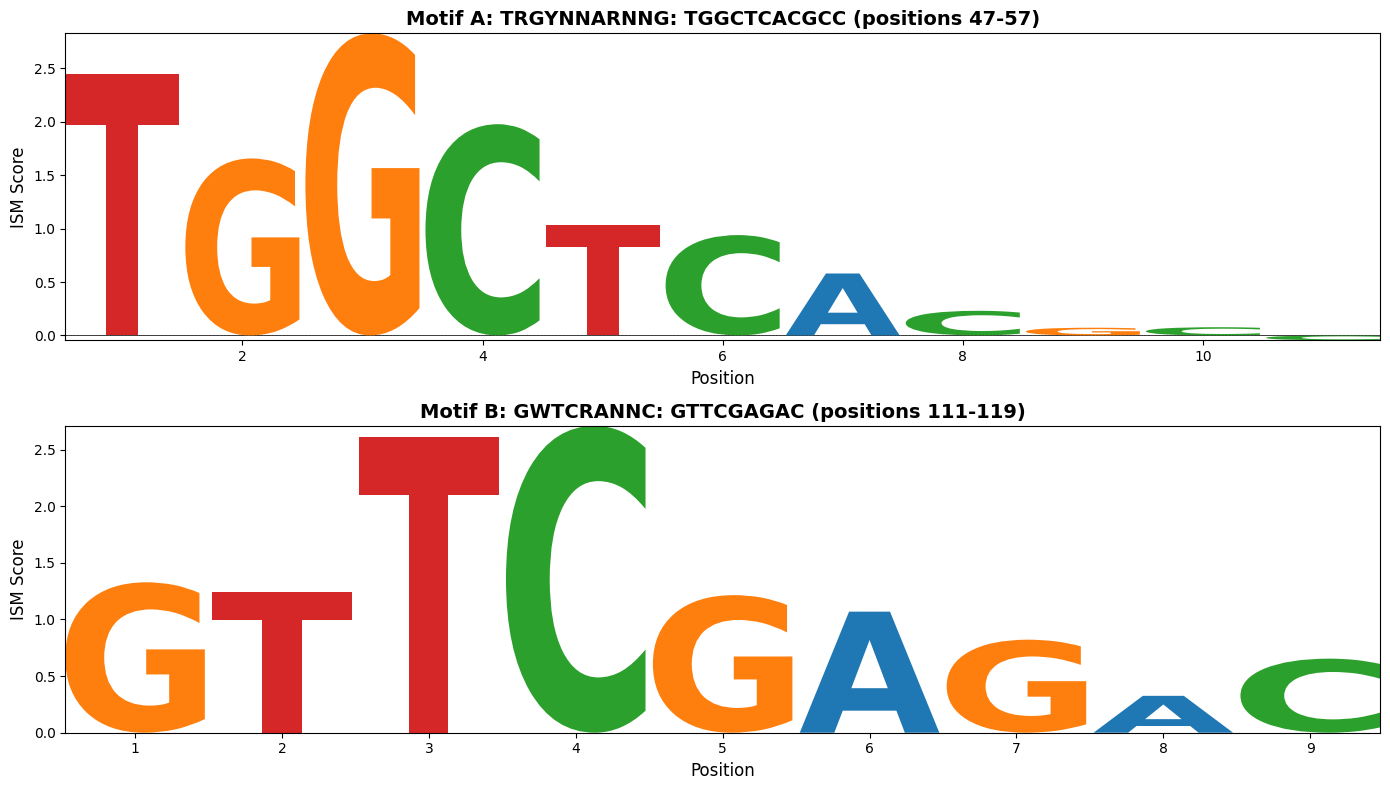

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import logomaker

# IUPAC nucleotide codes
IUPAC_CODES = {
    'A': ['A'],
    'C': ['C'],
    'G': ['G'],
    'T': ['T'],
    'R': ['A', 'G'],
    'Y': ['C', 'T'],
    'W': ['A', 'T'],
    'S': ['C', 'G'],
    'M': ['A', 'C'],
    'K': ['G', 'T'],
    'N': ['A', 'C', 'G', 'T']
}

def matches_iupac(base, iupac_code):
    """Check if a base matches an IUPAC code"""
    return base in IUPAC_CODES.get(iupac_code, [])

def count_mismatches(sequence, motif, start_pos):
    """Count mismatches between sequence and motif starting at position"""
    if start_pos + len(motif) > len(sequence):
        return float('inf')
    
    mismatches = 0
    for i, motif_base in enumerate(motif):
        seq_base = sequence[start_pos + i]
        if not matches_iupac(seq_base, motif_base):
            mismatches += 1
    
    return mismatches

def find_best_motif_match(sequence, motif, max_mismatches=2):
    """Find best match for motif in sequence allowing up to max_mismatches"""
    best_position = None
    best_mismatches = float('inf')
    best_match_seq = None
    
    for i in range(len(sequence) - len(motif) + 1):
        mismatches = count_mismatches(sequence, motif, i)
        if mismatches <= max_mismatches and mismatches < best_mismatches:
            best_mismatches = mismatches
            best_position = i
            best_match_seq = sequence[i:i+len(motif)]
    
    return best_position, best_mismatches, best_match_seq

def create_ism_logo_data(sequence_match, ism_scores, start_position):
    """Create position weight matrix from ISM scores for logo plot"""
    motif_length = len(sequence_match)
    
    # Create dataframe for logomaker
    logo_data = []
    
    for i, base in enumerate(sequence_match):
        pos = start_position + i
        score = ism_scores.get(pos, 0)
        
        # Create entry for each nucleotide
        row = {'position': i + 1}
        for nuc in ['A', 'C', 'G', 'T']:
            if nuc == base:
                # Use ISM score for the actual base
                row[nuc] = score
            else:
                # Other bases get zero or small negative value
                row[nuc] = 0
        
        logo_data.append(row)
    
    return pd.DataFrame(logo_data).set_index('position')

def plot_motif_ism_logo(sequence_match, ism_scores, start_position, motif_name, ax=None):
    """Plot sequence logo with ISM scores"""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    
    # Color scheme
    color_scheme = {
        'A': '#1f77b4',  
        'C': '#2ca02c', 
        'G': '#ff7f0e',  
        'T': '#d62728',  
    }
    
    # Create logo data
    logo_df = create_ism_logo_data(sequence_match, ism_scores, start_position)
    
    # Create logo
    logo = logomaker.Logo(logo_df, 
                          ax=ax,
                          color_scheme=color_scheme,
                          font_name='Arial',
                          stack_order='big_on_top')
    
    # Styling
    ax.set_ylabel('ISM Score', fontsize=12)
    ax.set_xlabel('Position', fontsize=12)
    ax.set_title(f'{motif_name}: {sequence_match} (positions {start_position}-{start_position+len(sequence_match)-1})', 
                 fontsize=14, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--', alpha=0.3)
    
    return logo

def main():
    # Input data
    csv_file = '/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/3_windows/ism_logos/R_wL_ISM.csv'
    
    reference_sequence = "GTGCCAATCCATCCCAAACATAATAGTTACAGATTGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCGGATGGATCAGCTGAAGTCAGGAGTTCGAGACCAGCCTGGCCAACATGGTGAAACCTTGTCTCTACTAAAAATACAAATATTAGCCAGGCGTCGTCGTGGGTGCCTGTGATC"
    
    # Motifs to find
    motif_A = "TRGYNNARNNG"  # 11 bases
    motif_B = "GWTCRANNC"     # 9 bases
    
    # Load ISM scores
    df = pd.read_csv(csv_file)
    print(f"Original CSV: {len(df)} rows")
    
    # Remove first 15 ROWS and last 16 ROWS from the dataframe
    df_trimmed = df.iloc[15:-16].copy()
    print(f"After trimming: {len(df_trimmed)} rows")
    
    # Reset positions to be 0-indexed from the start of trimmed sequence
    df_trimmed['position'] = range(len(df_trimmed))
    
    # Create ISM scores dictionary
    ism_scores = dict(zip(df_trimmed['position'], df_trimmed['ISM_score']))
    
    # Trim the reference sequence to match (remove first 15 and last 16 bases)    
    print(f"Loaded {len(ism_scores)} ISM scores")
    print(f"Trimmed sequence length: {len(reference_sequence)}")
    print(f"\nSearching for specific sequences...")
    
    # Find specific sequence for motif A: TGGCTCACGCC
    target_seq_A = "TGGCTCACGCC"
    pos_A = reference_sequence.find(target_seq_A)
    
    if pos_A == -1:
        print(f"\nWARNING: Sequence {target_seq_A} not found in reference!")
        print("Searching for best match instead...")
        pos_A, mismatches_A, match_A = find_best_motif_match(reference_sequence, motif_A, max_mismatches=2)
    else:
        match_A = target_seq_A
        # Count mismatches with motif
        mismatches_A = count_mismatches(reference_sequence, motif_A, pos_A)
        
    print(f"\nMotif A ({motif_A}):")
    print(f"  Using sequence: {match_A}")
    print(f"  Position: {pos_A}")
    print(f"  Mismatches from motif: {mismatches_A}")
    
    # Find motif B
    pos_B, mismatches_B, match_B = find_best_motif_match(reference_sequence, motif_B, max_mismatches=2)
    print(f"\nMotif B ({motif_B}):")
    print(f"  Best match at position {pos_B} with {mismatches_B} mismatches")
    print(f"  Matched sequence: {match_B}")
    
    # Create plots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot motif A
    plot_motif_ism_logo(match_A, ism_scores, pos_A, f"Motif A: {motif_A}", ax=ax1)
    
    # Plot motif B
    plot_motif_ism_logo(match_B, ism_scores, pos_B, f"Motif B: {motif_B}", ax=ax2)
    
    plt.tight_layout()
    plt.savefig('/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/A_B_motif.svg', format="svg")
    print(f"\nSaved plot to motif_ism_logos.png")
    plt.show()
    
    # Return results
    return {
        'motif_A': {'position': pos_A, 'mismatches': mismatches_A, 'sequence': match_A},
        'motif_B': {'position': pos_B, 'mismatches': mismatches_B, 'sequence': match_B}
    }

if __name__ == "__main__":
    results = main()